In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler

In [3]:
du_lieu_mua_sam = {
    "Game ($50)": [2, 0, 1],
    "Phim ($30)": [1, 3, 1],
    "Nhạc ($20)": [0, 5, 1]
}

ds_kh = ["KH1", "KH2", "KH3"]

bang_gio_hang = pd.DataFrame(du_lieu_mua_sam, index=ds_kh)

print(bang_gio_hang)
print(bang_gio_hang["Game ($50)"])

tb = bang_gio_hang.to_csv("bao_Cao_ngay_35.csv")
if os.path.exists("bao_Cao_ngay_35.csv") :
    print("success") 
else: 
    print("error")

     Game ($50)  Phim ($30)  Nhạc ($20)
KH1           2           1           0
KH2           0           3           5
KH3           1           1           1
KH1    2
KH2    0
KH3    1
Name: Game ($50), dtype: int64
success


In [4]:
df_load = pd.read_csv("bao_Cao_ngay_35.csv", index_col=0)

print(df_load)
print(df_load.loc["KH1",:])
print(df_load.iloc[-1,2])
print(df_load[df_load["Game ($50)"] > 0])

du_lieu_loi = {
    "Khách hàng": ["KH1", "KH2", "KH3", "KH4"],
    "Tuổi": [25, np.nan, 22, 30], # KH2 giấu tuổi
    "Tiền tiêu ($)": [150, 200, None, 400] # KH3 bị lỗi hệ thống mất lịch sử
}

df_loi = pd.DataFrame(du_lieu_loi)
print(df_loi)
print(df_loi.dropna())
print(df_loi.fillna(0))

df_loi["Tuổi"] = df_loi["Tuổi"].fillna(df_loi["Tuổi"].mean().round(1))
df_loi["Tiền tiêu ($)"] = df_loi["Tiền tiêu ($)"].fillna(df_loi["Tiền tiêu ($)"].mean().round(1))
print(df_loi)

     Game ($50)  Phim ($30)  Nhạc ($20)
KH1           2           1           0
KH2           0           3           5
KH3           1           1           1
Game ($50)    2
Phim ($30)    1
Nhạc ($20)    0
Name: KH1, dtype: int64
1
     Game ($50)  Phim ($30)  Nhạc ($20)
KH1           2           1           0
KH3           1           1           1
  Khách hàng  Tuổi  Tiền tiêu ($)
0        KH1  25.0          150.0
1        KH2   NaN          200.0
2        KH3  22.0            NaN
3        KH4  30.0          400.0
  Khách hàng  Tuổi  Tiền tiêu ($)
0        KH1  25.0          150.0
3        KH4  30.0          400.0
  Khách hàng  Tuổi  Tiền tiêu ($)
0        KH1  25.0          150.0
1        KH2   0.0          200.0
2        KH3  22.0            0.0
3        KH4  30.0          400.0
  Khách hàng  Tuổi  Tiền tiêu ($)
0        KH1  25.0          150.0
1        KH2  25.7          200.0
2        KH3  22.0          250.0
3        KH4  30.0          400.0


In [5]:
data_sale = {
    "Khách hàng": ["Hải", "Lan", "Minh", "Châu", "Tuấn", "Mai"],
    "Thành phố": ["Hà Nội", "Hà Nội", "TP.HCM", "Đà Nẵng", "TP.HCM", "Hà Nội"],
    "Tuổi": [25, 30, 22, 28, 35, 24],
    "Doanh thu ($)": [150, 200, 300, 120, 400, 100]
}

df_sale = pd.DataFrame(data_sale)

print(df_sale)

print("doanh thu theo thành phố:\n ",df_sale.groupby("Thành phố")["Doanh thu ($)"].sum())
print("tuổi trung bình theo thành phố: \n", round(df_sale.groupby("Thành phố")["Tuổi"].mean(),2))

bao_cao_tong_hop = df_sale.groupby("Thành phố").agg({
    "Doanh thu ($)": "sum",
    "Tuổi": "mean"
})
print(bao_cao_tong_hop)

  Khách hàng Thành phố  Tuổi  Doanh thu ($)
0        Hải    Hà Nội    25            150
1        Lan    Hà Nội    30            200
2       Minh    TP.HCM    22            300
3       Châu   Đà Nẵng    28            120
4       Tuấn    TP.HCM    35            400
5        Mai    Hà Nội    24            100
doanh thu theo thành phố:
  Thành phố
Hà Nội     450
TP.HCM     700
Đà Nẵng    120
Name: Doanh thu ($), dtype: int64
tuổi trung bình theo thành phố: 
 Thành phố
Hà Nội     26.33
TP.HCM     28.50
Đà Nẵng    28.00
Name: Tuổi, dtype: float64
           Doanh thu ($)       Tuổi
Thành phố                          
Hà Nội               450  26.333333
TP.HCM               700  28.500000
Đà Nẵng              120  28.000000


In [6]:
data_nhan_vien = {
    "Mã NV": ["NV01", "NV02", "NV03", "NV04"],
    "Tên": ["Hải", "Lan", "Minh", "Châu"],
    "Phòng ban": ["IT", "Marketing", "Sales", "IT"]
}

data_luong = {
    "Mã NV": ["NV01", "NV02", "NV03", "NV05"], # Chú ý: Có NV05 không nằm trong bảng Nhân sự
    "Lương ($)": [1200, 1000, 1500, 800],
    "Thưởng ($)": [200, 150, 300, 50]
}

df_nv = pd.DataFrame(data_nhan_vien)
df_luong = pd.DataFrame(data_luong)


df_hoan_chinh = pd.merge(df_nv, df_luong, on="Mã NV", how="inner")
print(df_hoan_chinh)

df_hoan_chinh["Tổng thu nhập"] = df_hoan_chinh["Lương ($)"] + df_hoan_chinh["Thưởng ($)"]

print(df_hoan_chinh)



  Mã NV   Tên  Phòng ban  Lương ($)  Thưởng ($)
0  NV01   Hải         IT       1200         200
1  NV02   Lan  Marketing       1000         150
2  NV03  Minh      Sales       1500         300
  Mã NV   Tên  Phòng ban  Lương ($)  Thưởng ($)  Tổng thu nhập
0  NV01   Hải         IT       1200         200           1400
1  NV02   Lan  Marketing       1000         150           1150
2  NV03  Minh      Sales       1500         300           1800


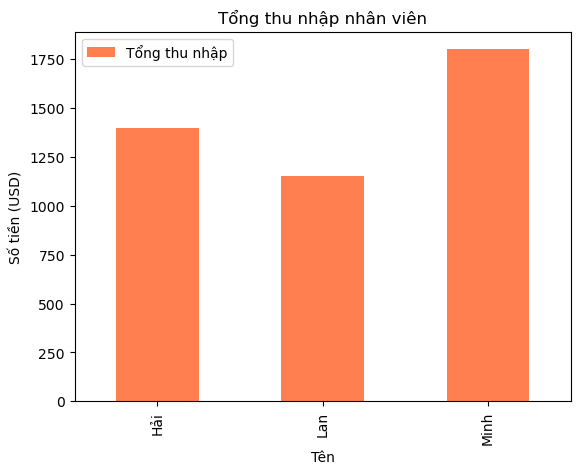

In [7]:
df_hoan_chinh.plot(kind="bar", x="Tên", y="Tổng thu nhập", color="coral", title="Tổng thu nhập nhân viên")
plt.ylabel("Số tiền (USD)")

plt.show()

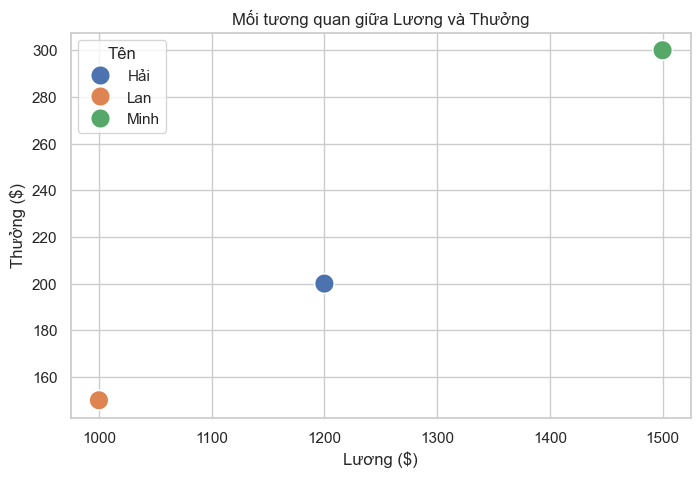

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_hoan_chinh,
    x="Lương ($)",
    y="Thưởng ($)",
    hue="Tên",
    s=200
)
# sns.regplot(
#     data=df_hoan_chinh, 
#     x="Lương ($)", 
#     y="Thưởng ($)", 
#     scatter_kws={'s':100}, # Chỉnh kích thước chấm tròn
#     line_kws={'color':'red'} # Chỉnh màu đường hồi quy
# )
# sns.lmplot(
#     data=df_hoan_chinh, 
#     x="Lương ($)", 
#     y="Thưởng ($)", 
#     hue="Phòng ban", # Vẽ đường xu hướng riêng cho mỗi phòng ban
#     height=5, 
#     aspect=1.5
# )
plt.title("Mối tương quan giữa Lương và Thưởng")
plt.show()

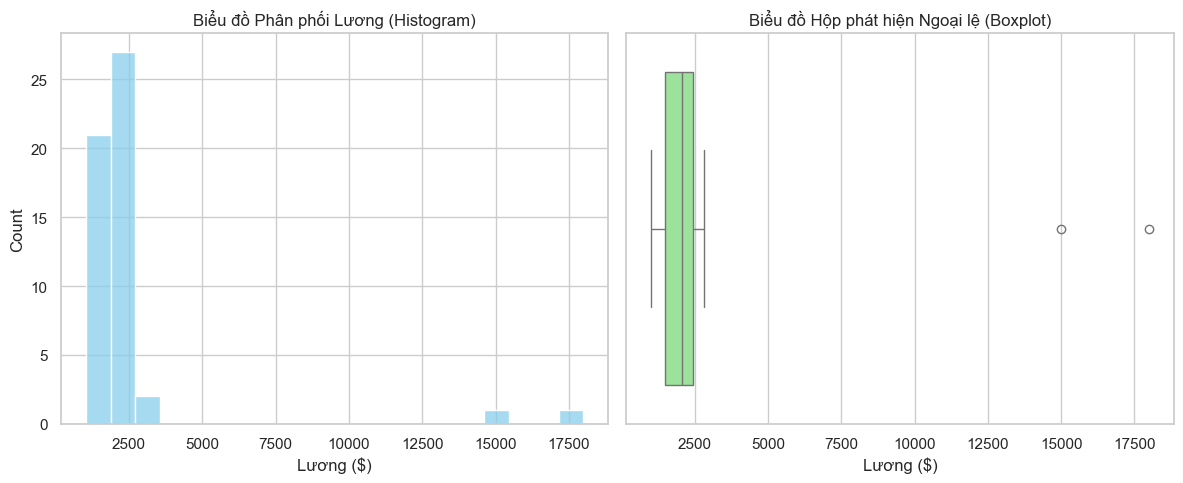

In [9]:
np.random.seed(42)
luong_nv = np.random.randint(1000, 3000, 50).tolist()
luong_nv.extend([15000, 18000])

df_luong_cty = pd.DataFrame({"Lương ($)": luong_nv})


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize= (12, 5))

sns.histplot(data=df_luong_cty, x="Lương ($)", bins=20, ax = axes[0], color="skyblue")
axes[0].set_title("Biểu đồ Phân phối Lương (Histogram)")

sns.boxplot(data=df_luong_cty, x="Lương ($)", ax=axes[1], color="lightgreen" )
axes[1].set_title("Biểu đồ Hộp phát hiện Ngoại lệ (Boxplot)")

plt.tight_layout()
plt.show()



--- CHUẨN HÓA DỮ LIỆU BẰNG SCIKIT-LEARN ---
   Lương ($)  Lương Z-score
0       2126      -0.137990
1       2459      -0.021364
2       1860      -0.231150
3       2294      -0.079151
4       2130      -0.136589
    Lương ($)  Lương Z-score
47       1189      -0.466152
48       1957      -0.197178
49       1686      -0.292089
50      15000       4.370835
51      18000       5.421517


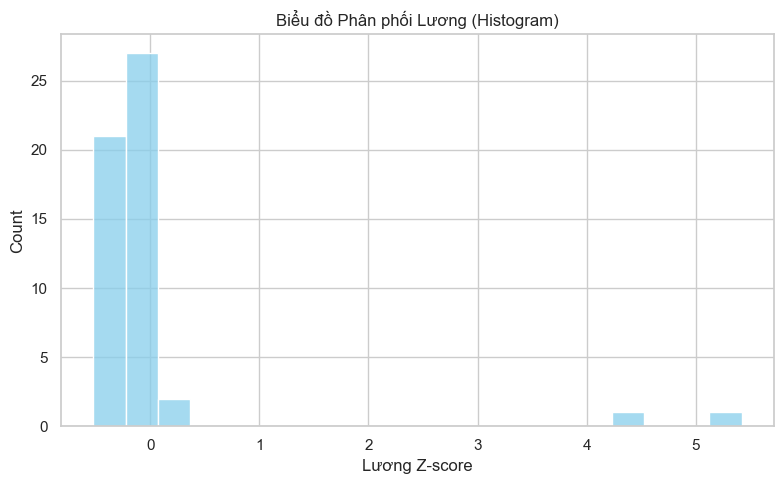

In [10]:
print("\n--- CHUẨN HÓA DỮ LIỆU BẰNG SCIKIT-LEARN ---")
scaler = StandardScaler()

luong_da_chuan_hoa = scaler.fit_transform(df_luong_cty[["Lương ($)"]])

df_luong_cty["Lương Z-score"] = luong_da_chuan_hoa

print(df_luong_cty.head())
print(df_luong_cty.tail())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5)) # Tạo khung hình mới
sns.histplot(data=df_luong_cty, x="Lương Z-score", bins=20, color="skyblue")
plt.title("Biểu đồ Phân phối Lương (Histogram)")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
np.random.seed(42)

df_luong_cty["Kinh nghiệm (năm)"] = np.random.randint(1,11,len(df_luong_cty))

# print(df_luong_cty)

X = df_luong_cty[["Kinh nghiệm (năm)"]]
y = df_luong_cty[["Lương ($)"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print(f"Kích thước X Train là: {X_train.shape}")
print(f"Kích thước X Test là: {X_test.shape}")
print(f"Kích thước y Train là: {y_train.shape}")
print(f"Kích thước y Test là: {y_test.shape}")

Kích thước X Train là: (41, 1)
Kích thước X Test là: (11, 1)
Kích thước y Train là: (41, 1)
Kích thước y Test là: (11, 1)


In [12]:
from sklearn.linear_model import LinearRegression

print("\n--- BẮT ĐẦU HUẤN LUYỆN AI ---")

#B1: khởi tạo mô hình
model = LinearRegression()

#B2:Dạy học
model.fit(X_train,y_train)

print("Trọng số (w - Hệ số góc): ", model.coef_)
print("Độ lệch (b - Điểm cắt trục tung): ", model.intercept_)

#B3: cho AI làm bài test
y_pred = model.predict(X_test)

ket_qua_thi = pd.DataFrame({
    "Lương thực tế: ": y_test.values.flatten(),
    "Lương AI dự đoán: ":np.round(y_pred.flatten(),2)
})

print("\n--- BẢNG SO SÁNH KẾT QUẢ ---")
print(ket_qua_thi)


--- BẮT ĐẦU HUẤN LUYỆN AI ---
Trọng số (w - Hệ số góc):  [[-290.36541889]]
Độ lệch (b - Điểm cắt trục tung):  [4073.11229947]

--- BẢNG SO SÁNH KẾT QUẢ ---
    Lương thực tế:   Lương AI dự đoán: 
0              1130             3492.38
1              1510             3492.38
2              1189             2911.65
3              1330             1750.19
4              2499             1459.82
5              2095             1169.46
6              1871             1750.19
7             15000             3202.02
8              2294             2621.29
9              1459             2621.29
10             2482             3202.02


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

print("\n--- CHẤM ĐIỂM MÔ HÌNH ---")

#1 tinh MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"1. MAE (Sai số trung bình): Lệch khoảng {mae:.2f} $")

#2 tinh MSE va RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
print(f"2. RMSE (Sai số chuẩn hóa): {rmse:.2f} $")

#3 tinh T2 score
r2 = r2_score(y_test, y_pred)
print(f"3. R-squared (Độ chính xác tương đối): {r2:.4f}")


--- CHẤM ĐIỂM MÔ HÌNH ---
1. MAE (Sai số trung bình): Lệch khoảng 2052.79 $
2. RMSE (Sai số chuẩn hóa): 3763.16 $
3. R-squared (Độ chính xác tương đối): 0.0341


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n--- BƯỚC 1: LÀM SẠCH VÀ TẠO QUY LUẬT DỮ LIỆU ---")
df_clean = df_luong_cty[df_luong_cty["Lương ($)"] < 10000].copy()

np.random.seed(42)

noise = np.random.randint(-200, 200, size=len(df_clean))
df_clean["Lương ($)"] = 1000 + (df_clean["Kinh nghiệm (năm)"] * 500) + noise

print(df_clean[["Kinh nghiệm (năm)", "Lương ($)"]].head())

print("\n--- BƯỚC 2: TRAIN LẠI MÔ HÌNH TỪ ĐẦU ---")

X_clean = df_clean[["Kinh nghiệm (năm)"]]
y_clean = df_clean[["Lương ($)"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

model_new = LinearRegression()
model_new.fit(X_train_s, y_train_s)

print("Trọng số (w - Hệ số góc): ", model_new.coef_)
print("Độ lệch (b - Điểm cắt trục tung): ", model_new.intercept_)

y_pred_s = model_new.predict(X_test_s)

ket_qua_thi_s = pd.DataFrame({
    "Lương thực tế: ": y_test_s.values.flatten(),
    "Lương Ai dự đoán: ": np.round(y_pred_s.flatten(),2)

})
print(ket_qua_thi_s)

mae_new = mean_absolute_error(y_test_s, y_pred_s)
print(f"1. MAE (Sai số trung bình): Lệch khoảng {mae_new:.2f} $")

mse_new = mean_squared_error(y_test_s, y_pred_s)
rmse_new = math.sqrt(mse_new)
print(f"2. RMSE (Sai số chuẩn hóa): {rmse_new:.2f} $")

r2_new = r2_score(y_test_s, y_pred_s)
print(f"3. R-squared (Độ chính xác tương đối): {r2_new:.4f}")



--- BƯỚC 1: LÀM SẠCH VÀ TẠO QUY LUẬT DỮ LIỆU ---
   Kinh nghiệm (năm)  Lương ($)
0                  7       4402
1                  4       3148
2                  8       5070
3                  5       3406
4                  7       4371

--- BƯỚC 2: TRAIN LẠI MÔ HÌNH TỪ ĐẦU ---
Trọng số (w - Hệ số góc):  [[509.92184627]]
Độ lệch (b - Điểm cắt trục tung):  [941.84001471]
   Lương thực tế:   Lương Ai dự đoán: 
0             2399             2471.61
1             3163             2981.53
2             5644             5531.14
3             3434             3491.45
4             4949             5021.21
5             4466             4511.29
6             6113             6041.06
7             1460             1451.76
8             3358             3491.45
9             2057             1961.68
1. MAE (Sai số trung bình): Lệch khoảng 85.08 $
2. RMSE (Sai số chuẩn hóa): 96.77 $
3. R-squared (Độ chính xác tương đối): 0.9957


In [16]:
print("\n--- NGÀY 48: HỒI QUY ĐA BIẾN (MULTIPLE REGRESSION) ---")

np.random.seed(42)

noise_m = np.random.randint(-200, 200, len(df_clean))
df_clean["Điểm KPI"] = np.random.randint(1, 11, size=len(df_clean))

df_clean["Lương ($)"] = 1000 + (df_clean["Kinh nghiệm (năm)"] * 500) + (df_clean["Điểm KPI"] * 200) + noise_m

X_multi = df_clean[["Kinh nghiệm (năm)", "Điểm KPI"]]
y_multi = df_clean[["Lương ($)"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_m =LinearRegression()
model_m.fit(X_train_m, y_train_m)

print("\nAI đã học xong Hồi quy đa biến!")
print("Trọng số (w1, w2):", np.round(model_m.coef_.flatten(), 2))
print("Độ lệch (b): ", np.round(model_m.intercept_, 2))

y_pred_m = model_m.predict(X_test_m)

ket_qua_thi_m = pd.DataFrame({
    "Lương thực tế": y_test_m.values.flatten(),
    "Lương AI dự đoán": np.round(y_pred_m.flatten(), 2)
})

print("1. MAE (sai số trung bình): ", mean_absolute_error(y_test_m, y_pred_m))
print("2. RMSE (sai số chuẩn hóa): ", math.sqrt(mean_squared_error(y_test_m, y_pred_m)))
print("3. R-squared (độ chính xác tương đối): ", r2_score(y_test_m, y_pred_m))


--- NGÀY 48: HỒI QUY ĐA BIẾN (MULTIPLE REGRESSION) ---

AI đã học xong Hồi quy đa biến!
Trọng số (w1, w2): [510.14 195.85]
Độ lệch (b):  [966.36]
1. MAE (sai số trung bình):  90.08919211024002
2. RMSE (sai số chuẩn hóa):  99.24660652632126
3. R-squared (độ chính xác tương đối):  0.9971033705272525
